# Set up

## Imports

In [28]:
import wec_as_multiport as wam
import wecopttool as wot
import capytaine as cpy
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter
import pandas as pd
from scipy.interpolate import CubicSpline

## pyplot settings

In [ ]:

tex_fonts = {
    # Use LaTeX to write all text
    "text.usetex": True,
    "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 10,
    "font.size": 10,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "grid.linestyle": '--',
    "grid.linewidth": '0.1',
    "grid.alpha": 0.25,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.minor.width": 0.25,
    "ytick.minor.width": 0.25,
}

plt.rcParams.update(tex_fonts)

## Artifact paths

In [30]:
gfx_path = os.path.join('gfx')
data_path = os.path.join('data')
base_name = 'wec_as_multiport_'

for dir in [gfx_path, data_path]:
    if not os.path.exists(dir):
        os.makedirs(dir)

## Constants

In [31]:
rho = 1e3
g = 9.81

## Frequency array

In [32]:
f1 = 0.025
nfreq = 60
freq = wot.frequency(f1, nfreq, False)  # False -> no zero frequency

## BEM

In [33]:
wb = wot.geom.WaveBot()  # use standard dimensions
mesh_size_factor = 0.5  # 1.0 for default, smaller to refine mesh
mesh = wb.mesh(mesh_size_factor)
lid_mesh = cpy.load_mesh(mesh).generate_lid(z=-0.01)
fb = cpy.FloatingBody(mesh, name="WaveBot", lid_mesh=lid_mesh)
fb.add_translation_dof(name="Heave")

In [34]:
bem_data_fname = os.path.join(data_path,'wec_as_multiport.nc')

if os.path.isfile(bem_data_fname):
    print("Found existing BEM file, loading")
    bem_data = wot.read_netcdf(bem_data_fname)
else:
    bem_data = wot.run_bem(fb, freq)
    bem_data = bem_data.assign_coords(
        freq=("omega", bem_data['omega'].values/2/np.pi))
    bem_data['freq'].attrs['long_name'] = 'Frequency'
    bem_data['freq'].attrs['units'] = 'Hz'
    bem_data['excitation_force'] = bem_data['diffraction_force'] + bem_data['Froude_Krylov_force']
    bem_data = wot.add_linear_friction(bem_data)
    wot.write_netcdf(bem_data_fname, bem_data)

Found existing BEM file, loading


## WEC object

In [35]:
wec = wam.WEC(omega=bem_data['omega'].values,
            N=12.4666,
            Kt=6.1745,
            Rw=0.5,
            Lw=0,
            Jd=2,
            Bd=1,
            Kd=0,
            Zi=np.squeeze(wot.hydrodynamic_impedance(bem_data)).values,
            Hexc=np.squeeze(bem_data['excitation_force'].values))

mask = (wec.freq >= 0.1) & (wec.freq <= 1)

# Results

## Intrinsic impedance

### Bode

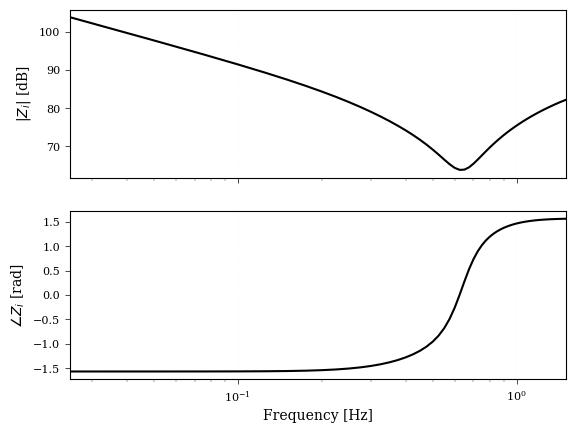

In [36]:
fig, ax = plt.subplots(nrows=2,
                       sharex=True)

ax[0].plot(wec.freq, 20*np.log10(np.abs(wec.Zi)), color='k')
ax[0].set_ylabel('$|Z_i|$ [dB]')

ax[1].plot(wec.freq, np.angle(wec.Zi), color='k')
ax[1].set_ylabel('$\\angle{Z_i}$ [rad]')

ax[-1].set_xlabel('Frequency [Hz]')

for axi in ax:
    axi.set_xscale('log')
    axi.autoscale(enable=True, axis='x', tight=True)
    axi.grid(which='major', axis='x')
    axi.set_title('')
    axi.label_outer()

### Real and imaginary

Text(0.5, 0, 'Frequency [Hz]')

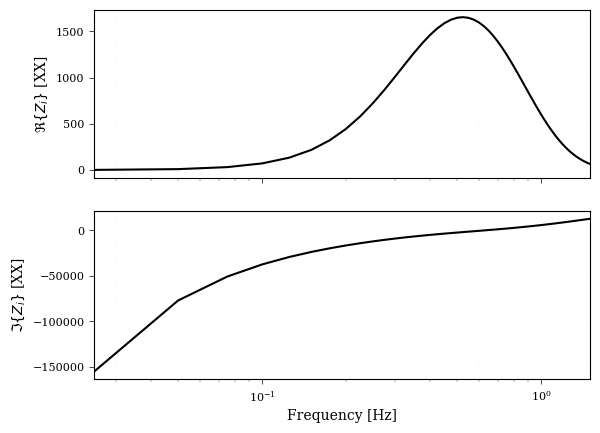

In [37]:
fig, ax = plt.subplots(nrows=2,
                       sharex=True)

ax[0].plot(wec.freq, np.real(wec.Zi), color='k')
ax[0].set_ylabel('$\\Re\{Z_i\}$ [XX]')

ax[1].plot(wec.freq, np.imag(wec.Zi), color='k')
ax[1].set_ylabel('$\\Im\{Z_i\}$ [XX]')

for axi in ax:
    axi.set_xscale('log')
    axi.autoscale(enable=True, axis='x', tight=True)
    axi.grid(which='both', axis='both')
    axi.set_title('')
    axi.label_outer()
    
ax[-1].set_xlabel('Frequency [Hz]')

## Excitation

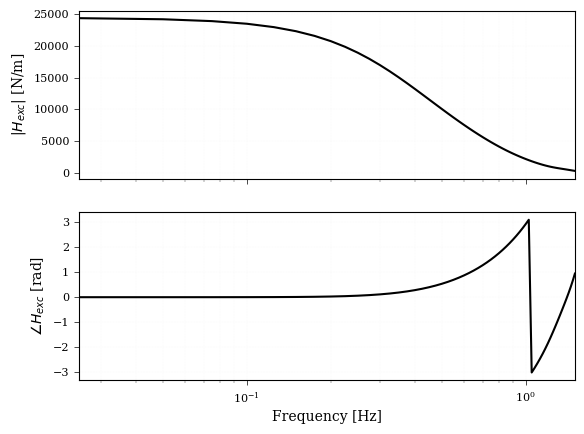

In [38]:
fig, ax = plt.subplots(nrows=2, sharex=True)

ax[0].plot(wec.freq, np.abs(wec.Hexc), color='k')
ax[1].plot(wec.freq, np.angle(wec.Hexc), color='k')

ax[0].set_ylabel('$| H_{exc} | $ [N/m]')
ax[1].set_ylabel('$\\angle{H_{exc}}$ [rad]')
ax[-1].set_xlabel('Frequency [Hz]')

for axi in ax:
    axi.set_xscale('log')
    axi.autoscale(enable=True, axis='x', tight=True)
    axi.grid(which='both', axis='both')
    axi.set_title('')
    axi.label_outer()

## Normalized response

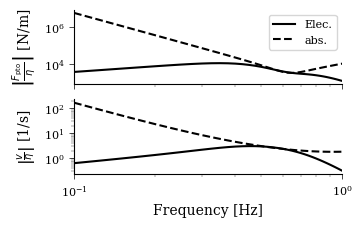

In [39]:
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=wam.util.figsize())

Fc = {
    'Elec.': wec.Hexc*(1 - wec.Zi/(wec.Zi + wec.Zin(Zl=wec.Zl_opt))),
    'abs.': wec.Hexc*(1 - wec.Zi/(wec.Zi + wec.Zin(Zl=wec.Zl_opt_abs))),
}

Vc = {
    'Elec.': wec.Hexc/(wec.Zi + wec.Zin(Zl=wec.Zl_opt)),
    'abs.': wec.Hexc/(wec.Zi + wec.Zin(Zl=wec.Zl_opt_abs))
}

for (k, v), ls in zip(Fc.items(), ['-','--']):
    ax[0].plot(wec.freq[mask], np.abs(v[mask]), c='k', ls=ls, label=k)
    ax[1].plot(wec.freq[mask], np.abs(Vc[k][mask]), c='k', ls=ls, label=k)
    
ax[0].set_ylabel('$\\left|\\frac{F_{\mathrm{pto}}}{\\eta}\\right|$ [N/m]')
ax[0].set_yscale('log')

ax[1].set_ylabel('$\\left|\\frac{v}{\\eta}\\right|$ [1/s]')
ax[1].set_yscale('log')

ax[0].legend()
ax[-1].set_xlabel('Frequency [Hz]')

for axi in ax:
    axi.spines[['right', 'top']].set_visible(False)
    axi.autoscale(enable=True, axis='x', tight=True)
    axi.label_outer()
    axi.set_xscale('log')
    axi.set_xlim([1e-1, 1])
    axi.xaxis.set_minor_formatter(NullFormatter())

## Controller design

### Controller impedances

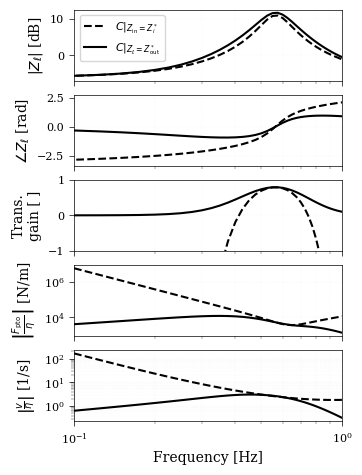

In [40]:
fig, ax = plt.subplots(nrows=5,
                       sharex=True,
                       figsize=wam.util.figsize(hf=2.5))


ls = {
        'abs': '$C \\vert_{Z_{\\mathrm{in}} = Z_i^*}$',
        'elec': '$C \\vert_{Z_\ell = Z_{\\mathrm{out}}^*}$',
}

ax[0].plot(wec.freq, 
           20*np.log10(np.abs(wec.Zl_opt_abs)),
           color='k', 
           ls='--', 
           label=ls['abs'])
ax[0].plot(wec.freq, 
           20*np.log10(np.abs(wec.Zl_opt)),
           color='k', 
           ls='-',
           label=ls['elec'])

ax[1].plot(wec.freq, 
           np.angle(wec.Zl_opt_abs),
           color='k', 
           ls='--', 
           label=ls['abs'])
ax[1].plot(wec.freq, 
           np.angle(wec.Zl_opt),
           color='k', 
           ls='-',
           label=ls['elec'])

ax[2].plot(wec.freq, 
           wec.transducer_power_gain(Zl=wec.Zl_opt), 
        ls='-', 
        color = 'k', 
        label=ls['elec'])

ax[2].plot(wec.freq,
           wec.transducer_power_gain(Zl=wec.Zl_opt_abs), 
        ls='--', 
        color = 'k', 
        label=ls['abs'])

ax[3].plot(wec.freq[mask], 
           np.abs(wec.Hexc[mask]/(1+wec.Zi[mask]/wec.Zin(Zl=wec.Zl_opt)[mask])),
           ls='-',
           color='k',
           label=ls['elec'])

ax[3].plot(wec.freq[mask], 
           np.abs(wec.Hexc[mask]/(1+wec.Zi[mask]/wec.Zin(Zl=wec.Zl_opt_abs)[mask])),
           ls='--',
           color='k',
           label=ls['abs'])

ax[4].plot(wec.freq[mask], 
           np.abs(wec.Hexc[mask]/(wec.Zi[mask] + wec.Zin(Zl=wec.Zl_opt)[mask])),
           ls='-',
           color='k',
           label=ls['elec'])

ax[4].plot(wec.freq[mask], 
           np.abs(wec.Hexc[mask]/(wec.Zi[mask] + wec.Zin(Zl=wec.Zl_opt_abs)[mask])),
           ls='--',
           color='k',
           label=ls['abs'])

for axi in ax:
    axi.set_xscale('log')
    axi.autoscale(enable=True, axis='x', tight=True)
    axi.grid(which='both', axis='both')
    axi.set_title('')
    axi.label_outer()
    axi.xaxis.set_minor_formatter(NullFormatter())
    axi.set_xlim([1e-1,1])
    axi.spines[['top','bottom','left','right']].set_linewidth(0.5)
    
ax[2].set_yscale('linear')
ax[2].set_ylim([-1,1])

ax[3].set_yscale('log')

ax[4].set_yscale('log')
    
ax[0].legend()
ax[-1].set_xlabel('Frequency [Hz]')

ax[0].set_ylabel('$|Z_\\ell|$ [dB]')
ax[1].set_ylabel('$\\angle{Z_\\ell}$ [rad]')
ax[2].set_ylabel('Trans.\ngain [ ]')
ax[3].set_ylabel('$\\left|\\frac{F_{\mathrm{pto}}}{\\eta}\\right|$ [N/m]')
ax[4].set_ylabel('$\\left|\\frac{v}{\\eta}\\right|$ [1/s]')

fig.savefig(os.path.join(gfx_path,base_name + 'load_impedance_for_mech_power_Bode.pdf'), bbox_inches = "tight")

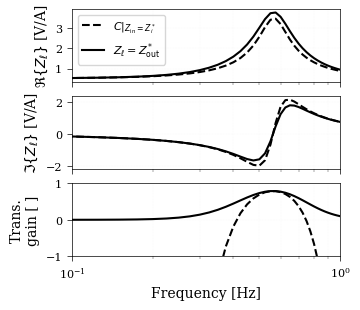

In [41]:
fig, ax = plt.subplots(nrows=3,
                       sharex=True,
                       figsize=wam.util.figsize(hf=1.5))

ax[0].plot(wec.freq, np.real(np.abs(wec.Zl_opt_abs)),
           color='k', 
           ls='--', 
           label='$C \\vert_{Z_{\\mathrm{in}} = Z_i^*}$')
ax[0].plot(wec.freq, np.real(np.abs(wec.Zl_opt)),
           color='k', 
           ls='-',
           label='$Z_\ell = Z_{\\mathrm{out}}^*$')

ax[1].plot(wec.freq, np.imag(wec.Zl_opt_abs),
           color='k', 
           ls='--', 
           label='$C \\vert_{Z_{\\mathrm{in}} = Z_i^*}$')
ax[1].plot(wec.freq, np.imag(wec.Zl_opt),
           color='k', 
           ls='-',
           label='$Z_\ell = Z_{\\mathrm{out}}^*$')

ax[2].plot(wec.freq, wec.transducer_power_gain(Zl=wec.Zl_opt), 
        ls='-', 
        color = 'k', 
        label='$Z_\ell = Z_{\\mathrm{out}}^*$')

ax[2].plot(wec.freq,wec.transducer_power_gain(Zl=wec.Zl_opt_abs), 
        ls='--', 
        color = 'k', 
        label='$C \\vert_{Z_{\\mathrm{in}} = Z_i^*}$')

for axi in ax:
    axi.set_xscale('log')
    axi.autoscale(enable=True, axis='x', tight=True)
    axi.grid(which='both', axis='both')
    axi.set_title('')
    axi.label_outer()
    axi.xaxis.set_minor_formatter(NullFormatter())
    axi.set_xlim([1e-1,1])
    axi.spines[['top','bottom','left','right']].set_linewidth(0.5)
    
ax[2].set_yscale('linear')
ax[2].set_ylim([-1,1])
    
ax[0].legend()
ax[-1].set_xlabel('Frequency [Hz]')

ax[0].set_ylabel('$\\Re \{ Z_\\ell \}$ [V/A]')
ax[1].set_ylabel('$\\Im \{ Z_\\ell \}$ [V/A]')
ax[2].set_ylabel('Trans.\ngain [ ]')

fig.savefig(os.path.join(gfx_path,base_name + 'load_impedance_for_mech_power_real_imag.pdf'), bbox_inches = "tight")

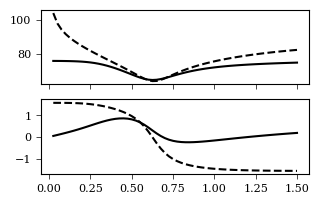

In [42]:
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=wam.util.figsize())

ax[0].plot(wec.freq, 20*np.log10(np.abs(wec.Zin(Zl=wec.Zl_opt))), c='k', ls='-')
ax[0].plot(wec.freq, 20*np.log10(np.abs(wec.Zin(Zl=wec.Zl_opt_abs))), c='k', ls='--')
# ax[0].set_yscale('log')

ax[1].plot(wec.freq, np.angle(wec.Zin(Zl=wec.Zl_opt)), c='k', ls='-')
ax[1].plot(wec.freq, np.angle(wec.Zin(Zl=wec.Zl_opt_abs)), c='k', ls='--')

## Thevenin impedance

0.55


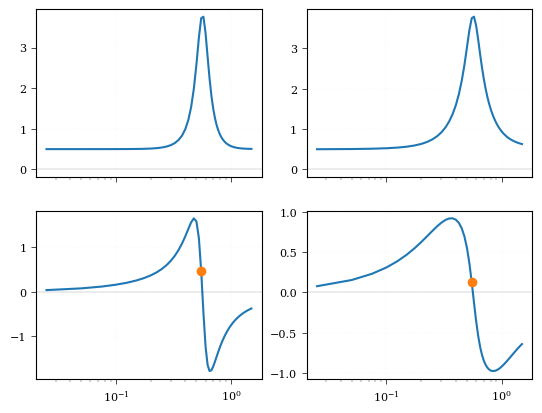

In [43]:
f = CubicSpline(wec.freq, np.imag(wec.Z_Thevenin))
x = np.linspace(wec.freq[0], wec.freq[-1], int(1e3))

ind1 = np.argmin(np.abs(f(x)))
ind = np.argmin(np.abs(x[ind1] - wec.freq))
print(wec.freq[ind])

fig, ax = plt.subplots(nrows=2,
                       ncols=2,
                       sharex=True)

ax[0][0].plot(wec.freq, np.real(wec.Z_Thevenin))
ax[1][0].plot(wec.freq, np.imag(wec.Z_Thevenin))

ax[0][1].plot(wec.freq, np.abs(wec.Z_Thevenin))
ax[1][1].plot(wec.freq, np.angle(wec.Z_Thevenin))

ax[1,0].plot(wec.freq[ind], np.imag(wec.Z_Thevenin)[ind],'o')
ax[1,1].plot(wec.freq[ind], np.angle(wec.Z_Thevenin)[ind],'o')

for axi in ax.flatten():
    axi.set_xscale('log')
    # axi.set_xlim((0.1,1))
    # axi.label_outer()
    axi.xaxis.set_minor_formatter(NullFormatter())
    axi.grid()
    axi.axhline(0, color='k', lw=0.1)

kp, ki: (2.44, -5.13)
kp, ki: (1.44, -0.55)
kp, ki: (1.58, 4.22)


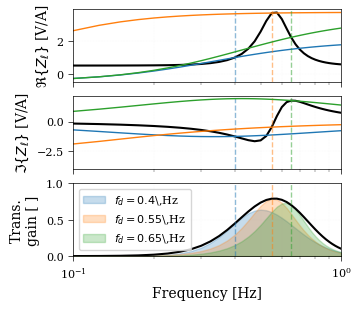

In [44]:
fig, ax = plt.subplots(nrows=3,sharex=True,figsize=wam.util.figsize(hf=1.5))

ax[0].plot(wec.freq[mask], np.real(wec.Zl_opt[mask]), 
           color='k', ls='-')
ax[1].plot(wec.freq[mask], np.imag(wec.Zl_opt[mask]), 
           color='k', ls='-')

ax[2].plot(wec.freq[mask], wec.transducer_power_gain()[mask], color='k')

# design_freqs = [0.55, 0.42, 0.35]
design_freqs = [0.4, 0.55, 0.65]
# colors = plt.get_cmap('Paired', len(design_freqs)).colors
colors = ['C0','C1','C2']

for design_freq, color in zip(design_freqs,colors):

    kp, ki = wec.pi_analytic(design_freq)
    print(f'kp, ki: ({kp:.2f}, {ki:.2f})')
    C = wec.pid_controller(kp=kp, ki=ki)
    Zl_C = wec.Zl_C(C)

    ax[0].plot(wec.freq[mask], np.real(Zl_C[mask]), 
            color=color, ls='-', lw=1)
    ax[1].plot(wec.freq[mask], np.imag(Zl_C[mask]), 
            color=color, ls='-', lw=1)

    ax[2].fill_between(wec.freq[mask], 
               wec.transducer_power_gain(Zl=Zl_C)[mask],
               color=color, alpha=0.25,
               label=f'$f_d={design_freq}$\,Hz')
    
    
    # print(np.trapz(wec.transducer_power_gain(Zl=Zl_C), wec.freq))
    
    for axi in ax:
        axi.axvline(design_freq, color=color, ls='--', lw=1, alpha=0.5)

# ax[2].set_yscale('log')

for axi in ax:
    axi.set_xscale('log')
    axi.autoscale(enable=True, axis='x', tight=True)
    axi.grid(which='both', axis='both')
    axi.set_title('')
    axi.label_outer()
    axi.xaxis.set_minor_formatter(NullFormatter())
    axi.set_xlim([1e-1,1])
    axi.spines[['top','bottom','left','right']].set_linewidth(0.5)
    
ax[1].set_ylim(bottom=-4)
ax[2].set_ylim(bottom=0)

ax[-1].set_xlabel('Frequency [Hz]')

ax[0].set_ylabel('$\\Re \{ Z_\\ell \}$ [V/A]')
ax[1].set_ylabel('$\\Im \{ Z_\\ell \}$ [V/A]')
ax[2].set_ylabel('Trans.\ngain [ ]')

ax[-1].legend()
ax[-1].set_ylim(top=1)

fig.savefig(os.path.join(gfx_path,base_name + 'pi_controllers_real_imag.pdf'), bbox_inches = "tight")

## Power output

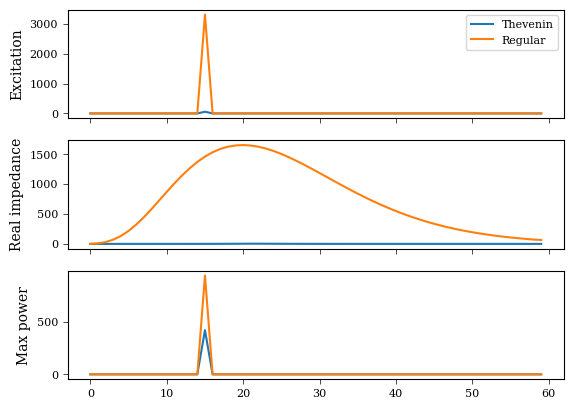

In [45]:
waves = wot.waves.regular_wave(f1=wec.f1, nfreq=wec.nfreq, freq=0.4, amplitude=0.25)
Fexc = wec.Fexc(waves=waves.squeeze().values)
Fth = wec.F_Thevenin(Fexc=Fexc)

fig, ax = plt.subplots(nrows=3, sharex=True)

ax[0].plot(np.abs(Fth), label='Thevenin')
ax[0].plot(np.abs(Fexc), label='Regular')
ax[0].set_ylabel('Excitation')

ax[1].plot(np.real(wec.Z_Thevenin))
ax[1].plot(np.real(wec.Zi))
ax[1].set_ylabel('Real impedance')

ax[2].plot(wec.max_active_power(Fexc=Fexc))
ax[2].plot(wec.max_active_power_abs(Fexc=Fexc))
ax[2].set_ylabel('Max power')

ax[0].legend()

In [46]:
# wot.waves.jonswap_spectrum(freq=wec.freq, fp=0.4, hs=1, gamma=1)
# wot.waves.long_crested_wave()

fp_list = [0.4, 0.5, 0.6]
pow_list = []

# wec.Rw = 0?

for fp in fp_list:
    # efth = wot.waves.omnidirectional_spectrum(wec.f1, 
    #                                         wec.nfrq, 
    #                                         lambda f: wot.waves.pierson_moskowitz_spectrum(f, fp, 0.2), 
    #                                         "Pierson-Moskowitz")
    # waves = wot.waves.long_crested_wave(efth, 1)
    waves = wot.waves.regular_wave(f1=wec.f1, nfreq=wec.nfreq, freq=fp, amplitude=0.25)
    Fexc = wec.Fexc(waves=waves.squeeze().values)
    pow = np.sum(wec.active_power(Fexc=Fexc, Zl=wec.Zl_opt))
    pow_list.append(pow)
    # print(pow)
    
df = pd.DataFrame(pow_list, fp_list, 
                  columns=['Elec. power [W]'])
df
# print(df.transpose().to_latex(float_format='%.1f'))

,Elec. power [W]
0.4,418.457618
0.5,354.430539
0.6,218.170318


# Compare different drive trains

kp, ki: (1.43, 0.58)
kp, ki: (1.40, 0.21)
kp, ki: (1.02, -0.09)
kp, ki: (1.43, 0.58)
kp, ki: (1.38, 0.67)
kp, ki: (1.20, 0.30)


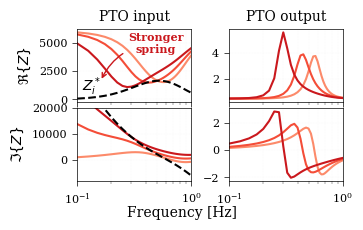

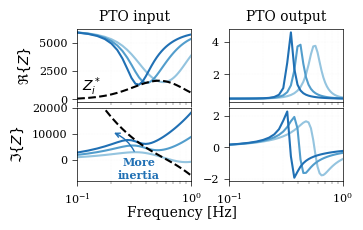

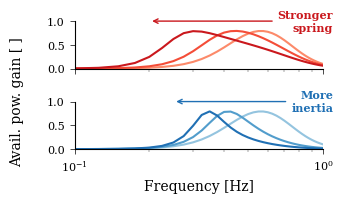

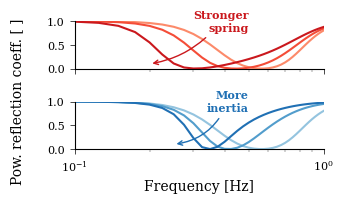

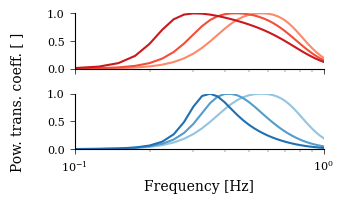

In [47]:
def make_design_var_plots(wec, var_name, values, colors):
    wec_list = []
    for val in values:
        wec_tmp = wec.copy()
        wec_tmp.__setattr__(var_name, val)
        wec_list.append(wec_tmp)

    fig, ax = plt.subplots(nrows=2,
                           ncols=2,
                           sharex=True,
                           figsize=wam.util.figsize())

    for wec1, color in zip(wec_list, colors):

        leg_string = '$Z_{\mathrm{in}}($' + f'{var_name}' + '$=$' + \
            f'{wec1.__getattribute__(var_name)})'

        ax[0, 0].plot(wec1.freq[mask], np.real(wec1.Zin()[mask]),
                      color=color,
                      label=leg_string)
        ax[1, 0].plot(wec1.freq[mask], np.imag(wec1.Zin()[mask]),
                      color=color,
                      label=leg_string)

        ax[0, 1].plot(wec1.freq[mask], np.real(wec1.Zout[mask]),
                      color=color,
                      label=leg_string)
        ax[1, 1].plot(wec1.freq[mask], np.imag(wec1.Zout[mask]),
                      color=color,
                      label=leg_string)

        # ax2.plot(wec1.freq[mask],
        #         wec1.transducer_power_gain(Zl=wec.Zl_opt)[mask],
        #         color=color,
        #         label=leg_string)

    ax[0, 0].plot(wec.freq[mask], np.real(np.conj(wec.Zi[mask])),
                  color='k',
                  ls='--',
                  label='$Z_i^*$')
    ax[1, 0].plot(wec.freq[mask], np.imag(np.conj(wec.Zi[mask])),
                  color='k',
                  ls='--',
                  label='$Z_i^*$')

    for axi in ax.flatten():
        axi.set_xscale('log')
        axi.autoscale(enable=True, axis='x', tight=True)
        axi.grid(which='both', axis='both')
        axi.set_title('')
        axi.xaxis.set_minor_formatter(NullFormatter())
        axi.spines[['top', 'bottom', 'left', 'right']].set_linewidth(0.5)

    ax[0, 0].set_ylabel('$\\Re\{Z\}$')
    ax[1, 0].set_ylabel('$\\Im\{Z\}$')

    # ax[1, 0].legend(ncol=2, fontsize='x-small')

    ax[0][0].set_title('PTO input', fontsize=10)
    ax[0][1].set_title('PTO output', fontsize=10)

    fig.supxlabel('Frequency [Hz]',
                  fontsize=10)

    fig.tight_layout(pad=0.1)

    return wec_list, fig


wec_designs = {
    'Kd': [],
    'Jd': []
}

my_colors = [
    plt.cm.Reds(np.linspace(0.4, 0.75, 3)),
    plt.cm.Blues(np.linspace(0.4, 0.75, 3)),
]

wec_designs['Kd'], fig = make_design_var_plots(wec,
                                               "Kd",
                                               np.linspace(0, -100, 3),
                                               my_colors[0],
                                               )

fig.get_axes()[2].set_ylim(top=2e4)

an = fig.get_axes()[0].annotate('Stronger\nspring',
                                xy=(0.16, 1.6e3),
                                xytext=(0.49, 4.1e3),
                                color=my_colors[0][-1],
                                fontsize=8,
                                fontweight='heavy',
                                ha='center',
                                arrowprops=dict(
                                    arrowstyle="->",
                                    connectionstyle="arc3,rad=0.3",
                                    color=my_colors[0][-1],
                                ))

fig.get_axes()[0].text(0.11, 8e2, '$Z_i^*$')

fig.savefig(os.path.join(gfx_path, base_name +
            'in_and_out_impedances_spring.pdf'), bbox_inches="tight")

wec_designs['Jd'], fig = make_design_var_plots(wec,
                                               "Jd",
                                               np.linspace(2, 20, 3),
                                               my_colors[1],
                                               )

fig.get_axes()[2].set_ylim(top=2e4)

fig.get_axes()[2].annotate('More\ninertia',
                           xy=(0.2, 1.1e4),
                           xytext=(0.35, -7e3),
                           color=my_colors[1][-1],
                           fontsize=8,
                           fontweight='heavy',
                           ha='center',
                           arrowprops=dict(
                               arrowstyle="->",
                               connectionstyle="arc3,rad=0.3",
                               color=my_colors[1][-1],
                           ))

fig.get_axes()[0].text(0.11, 8e2, '$Z_i^*$')

fig.savefig(os.path.join(gfx_path, base_name +
            'in_and_out_impedances_inertia.pdf'), bbox_inches="tight")

fig, ax = plt.subplots(figsize=wam.util.figsize(),
                       nrows=2,
                       sharex=True)

for (key, wecs), colors, axi in zip(wec_designs.items(), my_colors, ax):
    for wec1, color in zip(wecs, colors):
        axi.plot(wec1.freq, 
                 wec1.transducer_power_gain(Zl=wec1.Zl_opt),
                 ls='-',
                 color=color,
                 )
        
        kp, ki = wec1.pi_analytic(wec1.freq[np.argmax(wec1.transducer_power_gain(Zl=wec1.Zl_opt))])
        print(f'kp, ki: ({kp:.2f}, {ki:.2f})')
        C = wec1.pid_controller(kp=kp, ki=ki)
        Zl_C = wec1.Zl_C(C)
        
        eta = np.trapz(wec1.transducer_power_gain(Zl=Zl_C)) \
            / np.trapz(wec1.transducer_power_gain(Zl=wec1.Zl_opt))

        # axi.plot(wec1.freq,
        #          wec1.transducer_power_gain(Zl=Zl_C),
        #          ls='--',
        #          color=color,
        #          label=f'$\eta = {eta:.2f}$',
        #          )
        
        # axi.plot(wec1.freq,
        #          wec1.transducer_power_gain(Zl=Zl_C) /  wec1.transducer_power_gain(Zl=wec1.Zl_opt),
        #          ls='--',
        #          color=color,
        #          )
        

for axi in ax:

    axi.set_xlabel('Frequency [Hz]')
    axi.label_outer()
    axi.spines[['right', 'top']].set_visible(False)
    axi.set_ylim([0, 1])
    axi.autoscale(enable=True, axis='x', tight=True)
    axi.set_xscale('log')
    axi.set_xlim([1e-1, 1])
    axi.xaxis.set_minor_formatter(NullFormatter())
    # axi.legend()


fig.supylabel('Avail. pow. gain [ ]',
              fontsize=10,
              )

ax[0].annotate('Stronger\nspring',
               xy=(0.2, 1),
               xytext=(1.1, 1),
               color=my_colors[0][-1],
               fontsize=8,
               fontweight='heavy',
               ha='right',
               va='center',
               arrowprops=dict(
                   arrowstyle="->",
                   #    connectionstyle="arc3,rad=-0.3",
                   color=my_colors[0][-1],
               ))

ax[1].annotate('More\ninertia',
               xy=(0.25, 1),
               xytext=(1.1, 1),
               color=my_colors[1][-1],
               fontsize=8,
               fontweight='heavy',
               ha='right',
               va='center',
               arrowprops=dict(
                   arrowstyle="->",
                   #    connectionstyle="arc3,rad=-0.3",
                   color=my_colors[1][-1],
               ))

fig.tight_layout()

fig.savefig(os.path.join(gfx_path, base_name +
            'spring_inertia_transducer_gains.pdf'), bbox_inches="tight")

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=wam.util.figsize())

for (key, wecs), colors, axi in zip(wec_designs.items(), my_colors, ax):
    for wec1, color in zip(wecs, colors):
        gamma = wam.power_reflection_coefficient(Zs=wec1.Zi, Zl=wec1.Zin(Zl=wec1.Zl_opt))
        axi.plot(wec1.freq, gamma, c=color)
        
for axi in ax:

    axi.set_xlabel('Frequency [Hz]')
    axi.label_outer()
    axi.spines[['right', 'top']].set_visible(False)
    axi.set_ylim([0, 1])
    axi.autoscale(enable=True, axis='x', tight=True)
    axi.set_xscale('log')
    axi.set_xlim([1e-1, 1])
    axi.xaxis.set_minor_formatter(NullFormatter())
    # axi.legend()
    
fig.supylabel('Pow. reflection coeff. [ ]',
              fontsize=10,
              )

ax[0].annotate('Stronger\nspring',
               xy=(0.2, 0.1),
               xytext=(0.5, 1),
               color=my_colors[0][-1],
               fontsize=8,
               fontweight='heavy',
               ha='right',
               va='center',
               arrowprops=dict(
                   arrowstyle="->",
                   connectionstyle="arc3,rad=-0.2",
                   color=my_colors[0][-1],
               ))

ax[1].annotate('More\ninertia',
               xy=(0.25, 0.1),
               xytext=(0.5, 1),
               color=my_colors[1][-1],
               fontsize=8,
               fontweight='heavy',
               ha='right',
               va='center',
               arrowprops=dict(
                   arrowstyle="->",
                   connectionstyle="arc3,rad=-0.3",
                   color=my_colors[1][-1],
               ))

fig.tight_layout()

fig.savefig(os.path.join(gfx_path, base_name +
            'spring_inertia_power_reflection_coefficient.pdf'), bbox_inches="tight")

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=wam.util.figsize())

for (key, wecs), colors, axi in zip(wec_designs.items(), my_colors, ax):
    for wec1, color in zip(wecs, colors):
        gamma = wam.power_reflection_coefficient(Zs=wec1.Zi, Zl=wec1.Zin(Zl=wec1.Zl_opt))
        axi.plot(wec1.freq, 1-gamma, c=color)
        
for axi in ax:

    axi.set_xlabel('Frequency [Hz]')
    axi.label_outer()
    axi.spines[['right', 'top']].set_visible(False)
    axi.set_ylim([0, 1])
    axi.autoscale(enable=True, axis='x', tight=True)
    axi.set_xscale('log')
    axi.set_xlim([1e-1, 1])
    axi.xaxis.set_minor_formatter(NullFormatter())
    # axi.legend()
    
fig.supylabel('Pow. trans. coeff. [ ]',
              fontsize=10,
              )

fig.tight_layout()

fig.savefig(os.path.join(gfx_path, base_name +
            'spring_inertia_power_transmission_coefficient.pdf'), bbox_inches="tight")

## Power reflection coefficients

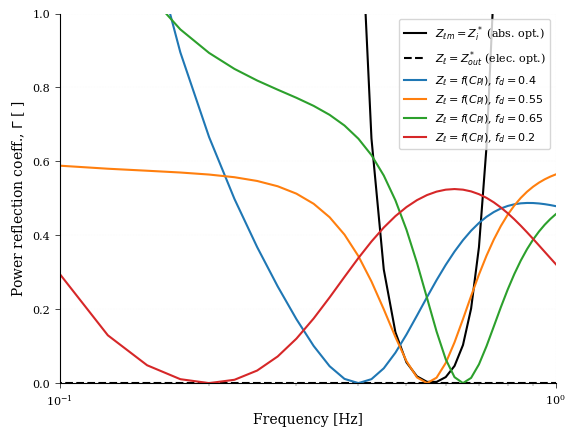

In [48]:
fig, ax = plt.subplots()

gamma_opt_abs = wam.power_reflection_coefficient(Zs=wec.Z_Thevenin,
                                                  Zl=wec.Zl_opt_abs)

gamma_opt = wam.power_reflection_coefficient(Zs=wec.Z_Thevenin,
                                             Zl=wec.Zl_opt)

ax.plot(wec.freq, gamma_opt_abs, c='k', ls='-',
        label='$Z_{\ell m}=Z_i^*$ (abs. opt.)')

ax.plot(wec.freq, gamma_opt, c='k', ls='--',
        label='$Z_{\ell}=Z_{out}^*$ (elec. opt.)')

ax.set_xlim(left=wec.freq[1])

for design_freq in design_freqs + [0.2]:
    kp, ki = wec.pi_analytic(design_freq)
    C = wec.pid_controller(kp=kp, ki=ki)
    Zl_C = wec.Zl_C(C)
    gamma_pi = wam.power_reflection_coefficient(Zs=wec.Z_Thevenin,
                                                Zl=Zl_C)

    ax.plot(wec.freq, gamma_pi, ls='-',
            label='$Z_\ell = f(C_{PI})$, ' + f'$f_d={design_freq}$')


ax.set_ylabel('Power reflection coeff., $\Gamma$ [ ]')
ax.set_xlabel('Frequency [Hz]')
# ax.set_yscale('log')
ax.set_ylim((1e-5, 1e2))
ax.set_ylim((0, 1))
ax.legend()

ax.spines[['right', 'top']].set_visible(False)
ax.autoscale(enable=True, axis='x', tight=True)
ax.set_xscale('log')
ax.set_xlim([1e-1, 1])
ax.xaxis.set_minor_formatter(NullFormatter())

ax.grid()

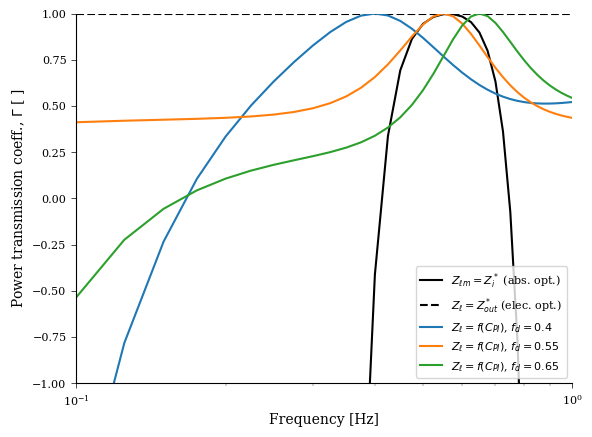

In [49]:
fig, ax = plt.subplots()

gamma_opt_abs = wam.power_transmission_coefficient(Zs=wec.Z_Thevenin,
                                                  Zl=wec.Zl_opt_abs)

gamma_opt = wam.power_transmission_coefficient(Zs=wec.Z_Thevenin,
                                             Zl=wec.Zl_opt)

ax.plot(wec.freq, gamma_opt_abs, c='k', ls='-',
        label='$Z_{\ell m}=Z_i^*$ (abs. opt.)')

ax.plot(wec.freq, gamma_opt, c='k', ls='--',
        label='$Z_{\ell}=Z_{out}^*$ (elec. opt.)')

ax.set_xlim(left=wec.freq[1])

for design_freq in design_freqs:
    kp, ki = wec.pi_analytic(design_freq)
    C = wec.pid_controller(kp=kp, ki=ki)
    Zl_C = wec.Zl_C(C)
    gamma_pi = wam.power_transmission_coefficient(Zs=wec.Z_Thevenin,
                                                Zl=Zl_C)

    ax.plot(wec.freq, gamma_pi, ls='-',
            label='$Z_\ell = f(C_{PI})$, ' + f'$f_d={design_freq}$')


ax.set_ylabel('Power transmission coeff., $\Gamma$ [ ]')
ax.set_xlabel('Frequency [Hz]')
# ax.set_yscale('log')
ax.set_ylim((1e-5, 1e2))
ax.set_ylim((-1, 1))
ax.legend()

ax.spines[['right', 'top']].set_visible(False)
ax.autoscale(enable=True, axis='x', tight=True)
ax.set_xscale('log')
ax.set_xlim([1e-1, 1])
ax.xaxis.set_minor_formatter(NullFormatter())

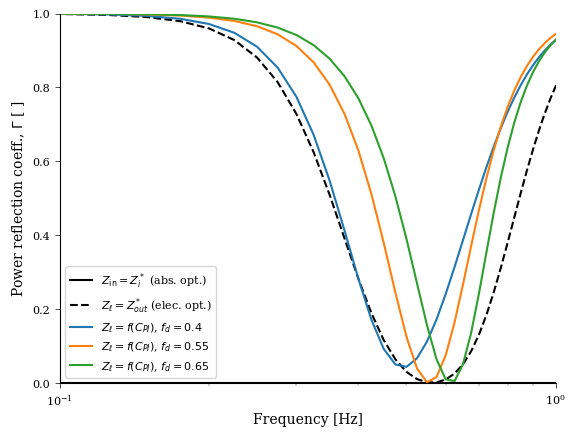

In [50]:
fig, ax = plt.subplots()

gamma_opt_abs = wam.power_reflection_coefficient(Zs=wec.Zi,
                                             Zl=wec.Zin(Zl=wec.Zl_opt_abs))

gamma_opt = wam.power_reflection_coefficient(Zs=wec.Zi,
                                             Zl=wec.Zin(Zl=wec.Zl_opt))

ax.plot(wec.freq, gamma_opt_abs, c='k', ls='-',
        label='$Z_{\mathrm{in}}=Z_i^*$ (abs. opt.)')

ax.plot(wec.freq, gamma_opt, c='k', ls='--',
        label='$Z_{\ell}=Z_{out}^*$ (elec. opt.)')

ax.set_xlim(left=wec.freq[1])

for design_freq in design_freqs:
    kp, ki = wec.pi_analytic(design_freq)
    C = wec.pid_controller(kp=kp, ki=ki)
    Zl_C = wec.Zl_C(C)
    gamma_pi = wam.power_reflection_coefficient(Zs=wec.Zi,
                                                Zl=wec.Zin(Zl=Zl_C))

    ax.plot(wec.freq, gamma_pi, ls='-',
            label='$Z_\ell = f(C_{PI})$, ' + f'$f_d={design_freq}$')


ax.set_ylabel('Power reflection coeff., $\Gamma$ [ ]')
ax.set_xlabel('Frequency [Hz]')
# ax.set_yscale('log')
ax.set_ylim((1e-5, 1e2))
ax.set_ylim((0, 1))
ax.legend()

ax.spines[['right', 'top']].set_visible(False)
ax.autoscale(enable=True, axis='x', tight=True)
ax.set_xscale('log')
ax.set_xlim([1e-1, 1])
ax.xaxis.set_minor_formatter(NullFormatter())

ax.grid()

Text(0, 0.5, '$\\Im \\{ Z \\}$')

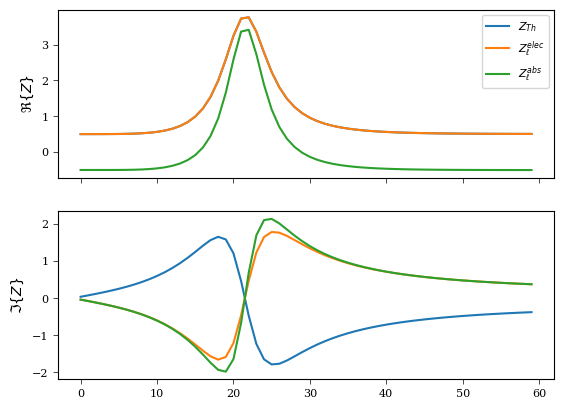

In [51]:
fig, ax = plt.subplots(nrows=2, sharex=True)

for Z, label in zip([wec.Z_Thevenin, wec.Zl_opt, wec.Zl_opt_abs], 
                    ['$Z_{Th}$', '$Z_\ell^{elec}$', '$Z_\ell^{abs}$']):
    
    ax[0].plot(np.real(Z),
               label=label,
               )
    ax[1].plot(np.imag(Z))
    
ax[0].legend()
ax[0].set_ylabel('$\Re \{ Z \}$')
ax[1].set_ylabel('$\Im \{ Z \}$')

# for axi in ax:
#     axi.spines[['right', 'top']].set_visible(False)
#     axi.autoscale(enable=True, axis='x', tight=True)
#     axi.set_xscale('log')
#     # axi.set_xlim([1e-1, 1])
#     axi.xaxis.set_minor_formatter(NullFormatter())

## Response spectra

elec
abs


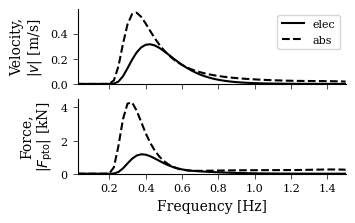

In [52]:
fp = 1/2.5
Hs = 1
spectrum = lambda f: wot.waves.pierson_moskowitz_spectrum(f, fp, Hs)
efth = wot.waves.omnidirectional_spectrum(f1, nfreq, spectrum, "Pierson-Moskowitz")
waves = wot.waves.long_crested_wave(efth, nrealizations=1)
Fexc = wec.Fexc(waves=waves.squeeze().values)

Fpto = {}
v = {}

Fpto['elec'], v['elec'] = wec.power_variables_in(Fexc=Fexc, Zl=wec.Zl_opt)
Fpto['abs'], v['abs'] = wec.power_variables_in(Fexc=Fexc, Zl=wec.Zl_opt_abs)

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=wam.util.figsize())

for k, ls in zip(Fpto.keys(), ['-','--']):
    print(k)
    ax[0].plot(wec.freq, np.abs(v[k].squeeze()), c='k', ls=ls, label=k)
    ax[1].plot(wec.freq, np.abs(Fpto[k].squeeze())/1e3, c='k', ls=ls, label=k)

ax[0].set_ylabel('Velocity,\n$|v|$ [m/s]')
ax[1].set_ylabel('Force,\n$|F_{\mathrm{pto}}|$ [kN]')

ax[0].legend()
ax[-1].set_xlabel('Frequency [Hz]')

for axi in ax:
    axi.set_ylim(bottom=0)
    axi.spines[['right', 'top']].set_visible(False)
    axi.autoscale(enable=True, axis='x', tight=True)
    axi.label_outer()

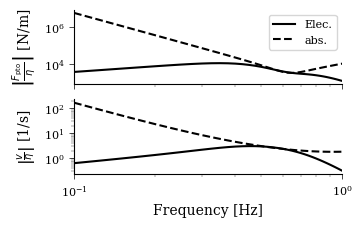

In [53]:
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=wam.util.figsize())

Fc = {
    'Elec.': wec.Hexc*(1 - wec.Zi/(wec.Zi + wec.Zin(Zl=wec.Zl_opt))),
    'abs.': wec.Hexc*(1 - wec.Zi/(wec.Zi + wec.Zin(Zl=wec.Zl_opt_abs))),
}

Vc = {
    'Elec.': wec.Hexc/(wec.Zi + wec.Zin(Zl=wec.Zl_opt)),
    'abs.': wec.Hexc/(wec.Zi + wec.Zin(Zl=wec.Zl_opt_abs))
}

for (k, v), ls in zip(Fc.items(), ['-','--']):
    ax[0].plot(wec.freq[mask], np.abs(v[mask]), c='k', ls=ls, label=k)
    ax[1].plot(wec.freq[mask], np.abs(Vc[k][mask]), c='k', ls=ls, label=k)
    
ax[0].set_ylabel('$\\left|\\frac{F_{\mathrm{pto}}}{\\eta}\\right|$ [N/m]')
ax[0].set_yscale('log')

ax[1].set_ylabel('$\\left|\\frac{v}{\\eta}\\right|$ [1/s]')
ax[1].set_yscale('log')

ax[0].legend()
ax[-1].set_xlabel('Frequency [Hz]')

for axi in ax:
    axi.spines[['right', 'top']].set_visible(False)
    axi.autoscale(enable=True, axis='x', tight=True)
    axi.label_outer()
    axi.set_xscale('log')
    axi.set_xlim([1e-1, 1])
    axi.xaxis.set_minor_formatter(NullFormatter())

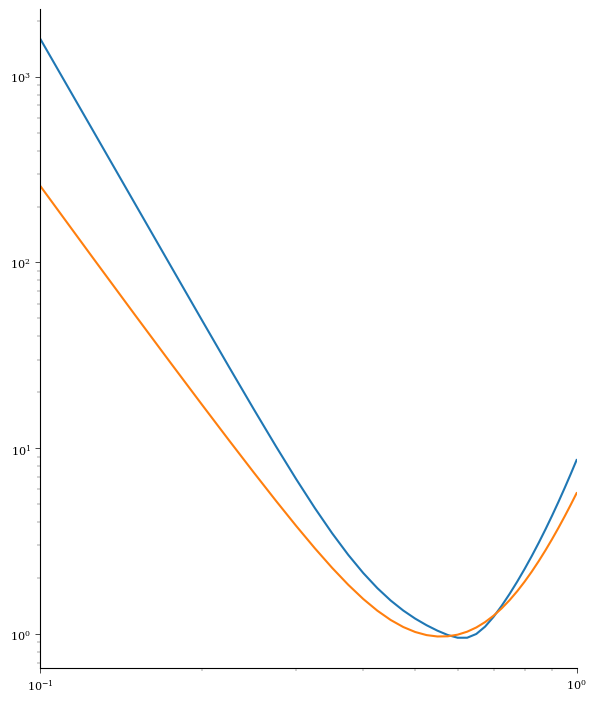

In [54]:
fig, ax = plt.subplots(nrows=1, figsize=wam.util.figsize(hf=2, wf=2))

Fc = {
    'Elec.': wec.Hexc*(1 - wec.Zi/(wec.Zi + wec.Zin(Zl=wec.Zl_opt))),
    'abs.': wec.Hexc*(1 - wec.Zi/(wec.Zi + wec.Zin(Zl=wec.Zl_opt_abs))),
}

Vc = {
    'Elec.': wec.Hexc/(wec.Zi + wec.Zin(Zl=wec.Zl_opt)),
    'abs.': wec.Hexc/(wec.Zi + wec.Zin(Zl=wec.Zl_opt_abs))
}

ax.plot(wec.freq[mask], np.abs(Fc['abs.'][mask].squeeze()/Fc['Elec.'][mask].squeeze()))
ax.plot(wec.freq[mask], np.abs(Vc['abs.'][mask].squeeze()/Vc['Elec.'][mask].squeeze()))

ax.set_yscale('log')
ax.spines[['right', 'top']].set_visible(False)
ax.autoscale(enable=True, axis='x', tight=True)
ax.label_outer()
ax.set_xscale('log')
ax.set_xlim([1e-1, 1])
ax.xaxis.set_minor_formatter(NullFormatter())